The Moving Average Crossover Strategy (Long-short)

Stock - Spice Islands Industries

We have two EMA filters viz. the shorter lookback period EMA (henceforth referred to as 'EMA50') and the longer lookback period EMA (henceforth referred to as 'EMA200').

Our trading rules can be stated as

Go long on day n+2 when EMA50 > EMA200 on day  n+1  and SMA50 < SMA200 on day n;

Go short on day n+2 when EMA50 < EMA200 on day  n+1  and SMA50 > SMA200 on day n.

In [14]:
import pandas as pd
import numpy as np
import datetime
import yfinance as yf
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# For quick, high-level, and interactive plots directly from pandas DataFrames
import plotly.express as px

%matplotlib inline

In [15]:
start1 = datetime.date(2010,1,1)
end1 = datetime.date(2026,5,29)
df = yf.download('SPICEISLIN.BO', start=start1, end=end1, interval='1d', auto_adjust=False)
df

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,SPICEISLIN.BO,SPICEISLIN.BO,SPICEISLIN.BO,SPICEISLIN.BO,SPICEISLIN.BO,SPICEISLIN.BO
Date,,,,,,
2010-01-04,13.162221,19.049999,19.100000,18.549999,19.000000,2700
2010-01-05,14.958641,21.650000,22.850000,19.000000,19.000000,25400
2010-01-06,14.854999,21.500000,23.000000,20.100000,22.000000,7000
2010-01-07,13.404046,19.400000,20.250000,19.100000,20.250000,5442
2010-01-08,13.818605,20.000000,21.000000,19.350000,21.000000,1900
...,...,...,...,...,...,...
2026-05-22,362.799988,362.799988,363.200012,352.000000,354.000000,17446
2026-05-25,367.750000,367.750000,376.000000,365.100006,369.950012,16502


In [16]:
df.columns = df.columns.droplevel(1)
df1 = df.copy()
df1

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2010-01-04,13.162221,19.049999,19.100000,18.549999,19.000000,2700
2010-01-05,14.958641,21.650000,22.850000,19.000000,19.000000,25400
2010-01-06,14.854999,21.500000,23.000000,20.100000,22.000000,7000
2010-01-07,13.404046,19.400000,20.250000,19.100000,20.250000,5442
2010-01-08,13.818605,20.000000,21.000000,19.350000,21.000000,1900
...,...,...,...,...,...,...
2026-05-22,362.799988,362.799988,363.200012,352.000000,354.000000,17446
2026-05-25,367.750000,367.750000,376.000000,365.100006,369.950012,16502
2026-05-26,375.600006,375.600006,378.500000,371.000000,374.000000,11529


<function matplotlib.pyplot.show(close=None, block=None)>

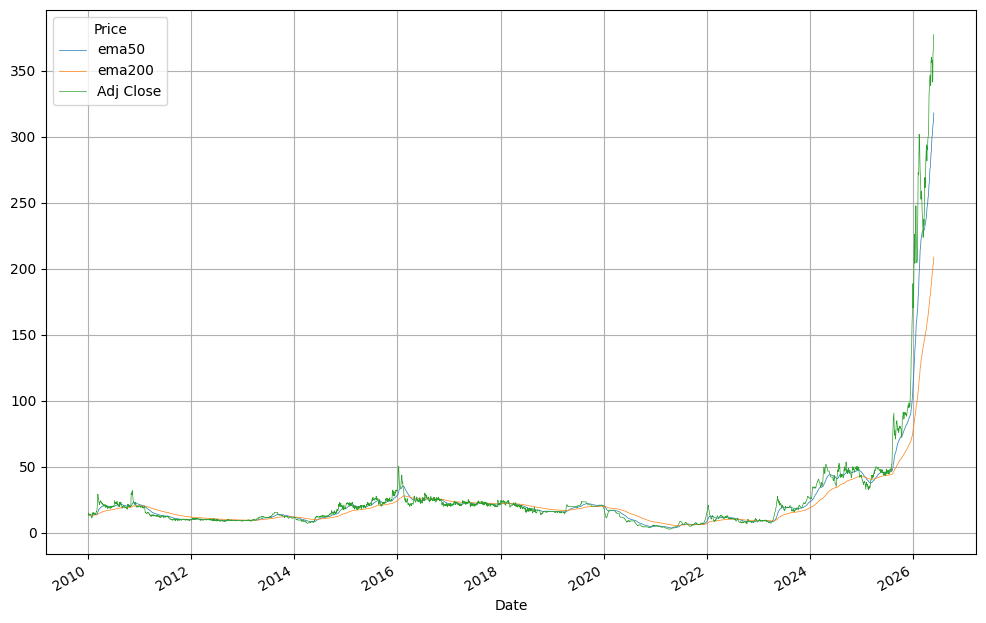

In [17]:
df1['ema50'] = df1['Adj Close'].ewm(span=50, adjust=False).mean()
df1['ema200'] = df1['Adj Close'].ewm(span=200, adjust=False).mean()

df1['ema50'] = df1['ema50'].shift(1)
df1['ema200'] = df1['ema200'].shift(1)

df1['ema50_prev_day'] = df1['ema50'].shift(1)
df1['ema200_prev_day'] = df1['ema200'].shift(1)

df1[['ema50','ema200','Adj Close']].plot(grid=True, linewidth=0.5, figsize=(12,8));
plt.show

In [18]:
df1['signal'] = np.where((df1['ema50']>df1['ema200']) & (df1['ema50_prev_day']<df1['ema200_prev_day']),1,0)

df1['signal'] = np.where((df1['ema50']<df1['ema200']) & (df1['ema50_prev_day']>df1['ema200_prev_day']),-1,df1['signal'])

In [19]:
df1['signal'].value_counts()

,count
signal,
0,4022
-1,11
1,11


In [23]:
df1['buy_price'] = df1.apply(lambda x: x['Adj Close'] if x['ema50']> x['ema200'] and x['ema50_prev_day']< x['ema200_prev_day'] else 0, axis=1)
df1['sell_price'] = df1.apply(lambda y: -y['Adj Close'] if y['ema50']< y['ema200'] and y['ema50_prev_day']> y['ema200_prev_day'] else 0, axis=1)

df1['trade_price'] = df1['buy_price'] + df1['sell_price']
df1['trade_price'] = df1['trade_price'].replace(to_replace=0, method='ffill')

In [24]:
df1['position'] = df1['signal'].replace(to_replace=0, method='ffill')
df1

Price,Adj Close,Close,High,Low,Open,Volume,ema50,ema200,ema50_prev_day,ema200_prev_day,signal,buy_price,sell_price,trade_price,position
Date,,,,,,,,,,,,,,,
2010-01-04,13.162221,19.049999,19.100000,18.549999,19.000000,2700,NaN,NaN,NaN,NaN,0,0.0,0.0,0.000000,0
2010-01-05,14.958641,21.650000,22.850000,19.000000,19.000000,25400,13.162221,13.162221,NaN,NaN,0,0.0,0.0,0.000000,0
2010-01-06,14.854999,21.500000,23.000000,20.100000,22.000000,7000,13.232669,13.180096,13.162221,13.162221,0,0.0,0.0,0.000000,0
2010-01-07,13.404046,19.400000,20.250000,19.100000,20.250000,5442,13.296290,13.196761,13.232669,13.180096,0,0.0,0.0,0.000000,0
2010-01-08,13.818605,20.000000,21.000000,19.350000,21.000000,1900,13.300515,13.198824,13.296290,13.196761,0,0.0,0.0,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-22,362.799988,362.799988,363.200012,352.000000,354.000000,17446,309.059686,202.458391,307.547836,201.014756,0,0.0,0.0,47.037987,1
2026-05-25,367.750000,367.750000,376.000000,365.100006,369.950012,16502,311.167149,204.053830,309.059686,202.458391,0,0.0,0.0,47.037987,1
2026-05-26,375.600006,375.600006,378.500000,371.000000,374.000000,11529,313.386084,205.682647,311.167149,204.053830,0,0.0,0.0,47.037987,1


In [26]:
df1['bnh_returns'] = np.log(df1['Adj Close']/df1['Adj Close'].shift(1))
df1['strategy_returns'] = df1['bnh_returns'] * df1['position'].shift(1)
df1

Price,Adj Close,Close,High,Low,Open,Volume,ema50,ema200,ema50_prev_day,ema200_prev_day,signal,buy_price,sell_price,trade_price,position,bnh_returns,strategy_returns
Date,,,,,,,,,,,,,,,,,
2010-01-04,13.162221,19.049999,19.100000,18.549999,19.000000,2700,NaN,NaN,NaN,NaN,0,0.0,0.0,0.000000,0,NaN,NaN
2010-01-05,14.958641,21.650000,22.850000,19.000000,19.000000,25400,13.162221,13.162221,NaN,NaN,0,0.0,0.0,0.000000,0,0.127938,0.000000
2010-01-06,14.854999,21.500000,23.000000,20.100000,22.000000,7000,13.232669,13.180096,13.162221,13.162221,0,0.0,0.0,0.000000,0,-0.006953,-0.000000
2010-01-07,13.404046,19.400000,20.250000,19.100000,20.250000,5442,13.296290,13.196761,13.232669,13.180096,0,0.0,0.0,0.000000,0,-0.102780,-0.000000
2010-01-08,13.818605,20.000000,21.000000,19.350000,21.000000,1900,13.300515,13.198824,13.296290,13.196761,0,0.0,0.0,0.000000,0,0.030459,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-22,362.799988,362.799988,363.200012,352.000000,354.000000,17446,309.059686,202.458391,307.547836,201.014756,0,0.0,0.0,47.037987,1,0.047124,0.047124
2026-05-25,367.750000,367.750000,376.000000,365.100006,369.950012,16502,311.167149,204.053830,309.059686,202.458391,0,0.0,0.0,47.037987,1,0.013552,0.013552
2026-05-26,375.600006,375.600006,378.500000,371.000000,374.000000,11529,313.386084,205.682647,311.167149,204.053830,0,0.0,0.0,47.037987,1,0.021121,0.021121


<function matplotlib.pyplot.show(close=None, block=None)>

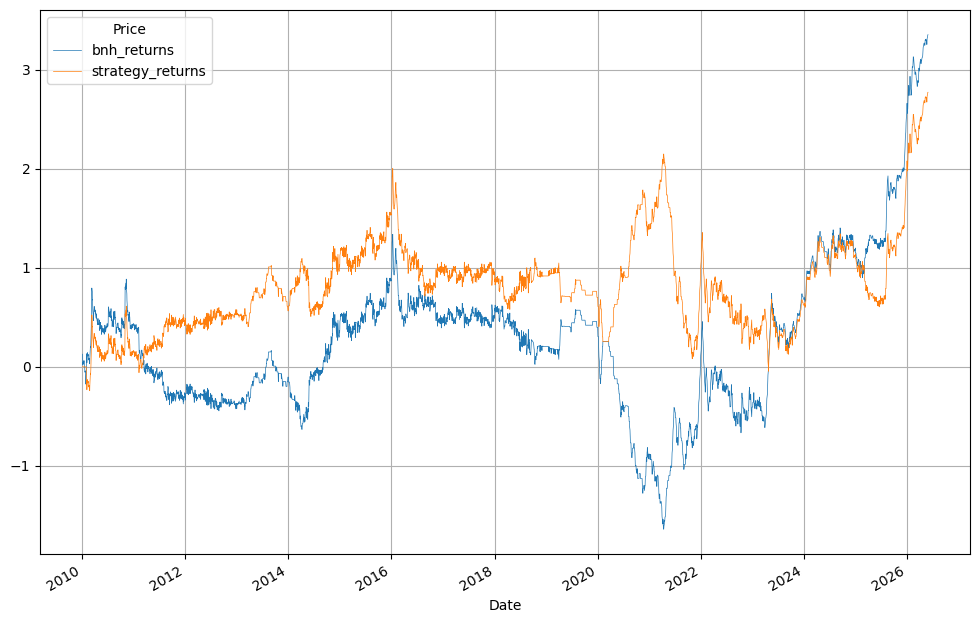

In [28]:
df1[['bnh_returns','strategy_returns']].cumsum().plot(grid=True, linewidth=0.5, figsize=(12,8));
plt.show

In [29]:
print('Buy and hold returns: ', np.round(df1['bnh_returns'].cumsum()[-1], 2))
print('Strategy returns: ', np.round(df1['strategy_returns'].cumsum()[-1], 2))

Buy and hold returns:  3.36
Strategy returns:  2.77
